# Part 1: Probability Distributions, EM Algorithm from Scratch

**Dataset:** [Galton parents vs children heights](https://www.kaggle.com/datasets/jacopoferretti/parents-heights-vs-children-heights-galton-data)

We pooled **fathers' heights** and **children's (daughters') heights** into
one sample with no labels, and treat it as a **mixture of two Gaussians**.
The job of the EM algorithm is to recover the two hidden populations
without ever seeing who is who.

**Why daughters?** The "children" in the Galton data are adult offspring.
Adult sons are basically as tall as fathers (both around 69 in), so if we
pool all children with fathers, the real bimodality in the data becomes
male vs female, and EM would find the gender split instead of the
child/parent split. Controlling for gender gives us two well defined
populations: children (daughters, about 64 in) vs fathers (about 69 in).
We actually verify this claim at the end of the notebook.

The mixture model:

$$p(x) = \pi_1 \, \mathcal{N}(x \mid \mu_1, \sigma_1^2) + \pi_2 \, \mathcal{N}(x \mid \mu_2, \sigma_2^2)$$

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from em_gmm import (fit_em, classify_height, naive_mean_split,
                    gaussian_pdf, e_step)

## 1. Load and pool the data

We take one father height per family (fathers repeat across rows in this
dataset) plus every daughter's height. Units are inches.

In [2]:
df = pd.read_csv("../data/GaltonFamilies.csv")
fathers = df.drop_duplicates("family")["father"].to_numpy(dtype=float)
children = df[df["gender"] == "female"]["childHeight"].to_numpy(dtype=float)
heights = np.concatenate([children, fathers])   # unlabeled mixture

print(f"fathers:  n={len(fathers)},  true mean={fathers.mean():.2f} in, sd={fathers.std():.2f}")
print(f"children: n={len(children)}, true mean={children.mean():.2f} in, sd={children.std():.2f}")
print(f"pooled (unlabeled): n={len(heights)}, global mean={heights.mean():.2f} in")

fathers:  n=205,  true mean=69.32 in, sd=2.64
children: n=453, true mean=64.10 in, sd=2.35
pooled (unlabeled): n=658, global mean=65.73 in


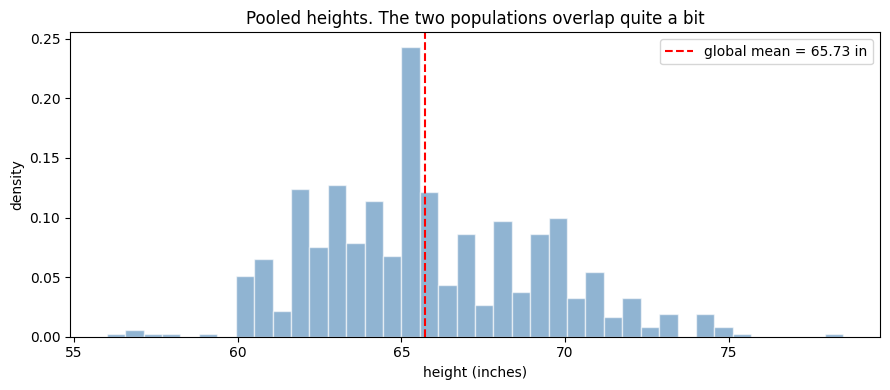

In [3]:
plt.figure(figsize=(9, 4))
plt.hist(heights, bins=40, density=True, alpha=0.6, color="steelblue",
         edgecolor="white")
plt.axvline(heights.mean(), color="red", ls="--",
            label=f"global mean = {heights.mean():.2f} in")
plt.title("Pooled heights. The two populations overlap quite a bit")
plt.xlabel("height (inches)"); plt.ylabel("density"); plt.legend()
plt.tight_layout(); plt.savefig("../docs/img_pooled_hist.png", dpi=120)
plt.show()

## 2. Why not just split at the global mean?

The naive recipe would be: draw a line at the global mean, put everything
below it in pile 1 and everything above in pile 2, then average each pile.
We argue this is a bad idea, for a few reasons:

1. **Misclassification in the overlap region.** The two Gaussians overlap,
   so a tall daughter lands above the line and a short father below it.
   Both piles end up contaminated with points from the wrong group.
2. **Truncation bias.** Cutting a Gaussian at a threshold and averaging
   each half gives the mean of a *truncated* distribution. This
   systematically pushes the two estimated means apart from the true ones.
3. **Hard vs soft assignment.** A hard cut throws away all uncertainty.
   EM instead gives every point a *responsibility* (the posterior
   probability of belonging to each component) and weights it accordingly,
   so points near the boundary count partially toward both components.
4. A single threshold also ignores that the groups have **different
   variances and different sizes** ($\pi_1 \neq \pi_2$).

In [4]:
lo_mean, hi_mean, split = naive_mean_split(heights)
print(f"naive split at {split:.2f} in -> pile means {lo_mean:.2f} / {hi_mean:.2f}")
print(f"true means:                    {children.mean():.2f} / {fathers.mean():.2f}")
print("The naive means are biased. EM below gets much closer.")

naive split at 65.73 in -> pile means 63.22 / 68.87
true means:                    64.10 / 69.32
The naive means are biased. EM below gets much closer.


## 3. Run EM and show the tracking table

* **E-step:** with the parameters fixed, compute each point's
  responsibility using Bayes' theorem:
  $\gamma_{ik} = \frac{\pi_k \mathcal{N}(x_i|\mu_k,\sigma_k^2)}{\sum_j \pi_j \mathcal{N}(x_i|\mu_j,\sigma_j^2)}$
* **M-step:** with the responsibilities fixed, update $\mu_k, \sigma_k^2, \pi_k$
  using responsibility-weighted averages (soft counts).
* **Stopping:** we iterate until the log-likelihood, which never decreases
  in EM, changes by less than a small tolerance.

In [5]:
params, history = fit_em(heights, max_iter=2000, tol=1e-6)

track = pd.DataFrame(history).rename(columns={
    "mu1": "mu1 (Children)", "mu2": "mu2 (Fathers)",
    "var1": "sigma1^2", "var2": "sigma2^2"})
print("Required tracking table (initialization + first two iterations):")
print(track.head(3).to_string(index=False))
print(f"\nConverged after {len(history)-1} iterations. Final parameters:")
print(track.tail(1).to_string(index=False))

Required tracking table (initialization + first two iterations):
 iteration  mu1 (Children)  mu2 (Fathers)  sigma1^2  sigma2^2      pi1      pi2  log_likelihood
         0       63.224590      68.865411  2.937975  5.234523 0.500000 0.500000    -1748.919705
         1       63.321326      68.613342  3.501893  6.504352 0.545261 0.454739    -1732.965281
         2       63.418779      68.546068  3.817840  7.117405 0.549658 0.450342    -1729.890729

Converged after 370 iterations. Final parameters:
 iteration  mu1 (Children)  mu2 (Fathers)  sigma1^2  sigma2^2      pi1      pi2  log_likelihood
       370       63.794741      68.868409  4.749997  7.349007 0.618999 0.381001    -1727.701403


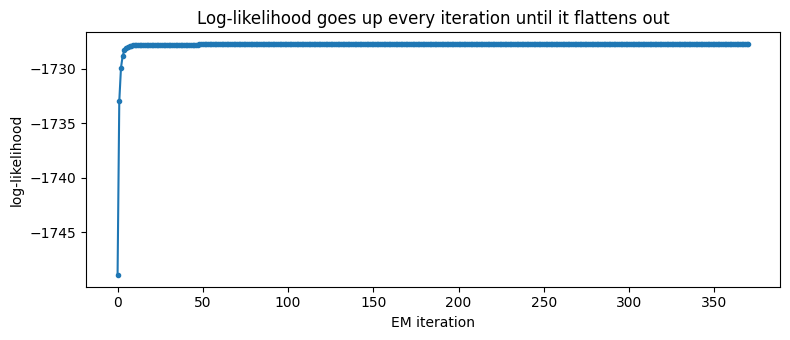

In [6]:
lls = [h["log_likelihood"] for h in history]
plt.figure(figsize=(8, 3.5))
plt.plot(lls, marker="o", ms=3)
plt.title("Log-likelihood goes up every iteration until it flattens out")
plt.xlabel("EM iteration"); plt.ylabel("log-likelihood")
plt.tight_layout(); plt.savefig("../docs/img_loglikelihood.png", dpi=120)
plt.show()

## 4. Fitted mixture vs the data

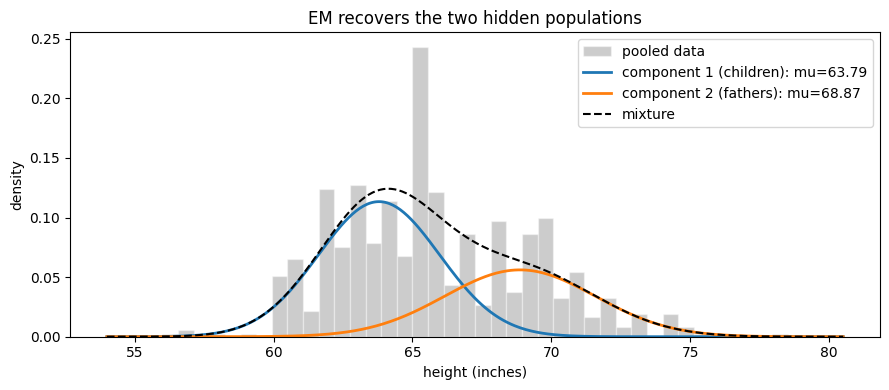

In [7]:
xs = np.linspace(heights.min() - 2, heights.max() + 2, 400)
p1 = params["pi1"] * gaussian_pdf(xs, params["mu1"], params["var1"])
p2 = params["pi2"] * gaussian_pdf(xs, params["mu2"], params["var2"])

plt.figure(figsize=(9, 4))
plt.hist(heights, bins=40, density=True, alpha=0.4, color="grey",
         edgecolor="white", label="pooled data")
plt.plot(xs, p1, lw=2, label=f"component 1 (children): mu={params['mu1']:.2f}")
plt.plot(xs, p2, lw=2, label=f"component 2 (fathers): mu={params['mu2']:.2f}")
plt.plot(xs, p1 + p2, "k--", lw=1.5, label="mixture")
plt.title("EM recovers the two hidden populations")
plt.xlabel("height (inches)"); plt.ylabel("density"); plt.legend()
plt.tight_layout(); plt.savefig("../docs/img_fitted_mixture.png", dpi=120)
plt.show()

## 5. Classification power: posterior probability for a test height

During the presentation the coach gives us a random height. We just change
`test_height` below and re-run the cell. The model prints the exact
posterior probability of each population using Bayes' theorem.

In [8]:
def report(height):
    post = classify_height(height, params)
    print(f"Test height = {height} in")
    for label, p in post.items():
        print(f"  P({label:8s} | height) = {p:.4f}  ({p*100:.2f}%)")
    winner = max(post, key=post.get)
    print(f"  => classified as: {winner}\n")

test_height = 66.0          # <- replace with the coach's number live
report(test_height)
for h in [62.0, 68.5, 71.0, 75.0]:
    report(h)

Test height = 66.0 in
  P(Children | height) = 0.6795  (67.95%)
  P(Fathers  | height) = 0.3205  (32.05%)
  => classified as: Children

Test height = 62.0 in
  P(Children | height) = 0.9727  (97.27%)
  P(Fathers  | height) = 0.0273  (2.73%)
  => classified as: Children

Test height = 68.5 in
  P(Children | height) = 0.1655  (16.55%)
  P(Fathers  | height) = 0.8345  (83.45%)
  => classified as: Fathers

Test height = 71.0 in
  P(Children | height) = 0.0115  (1.15%)
  P(Fathers  | height) = 0.9885  (98.85%)
  => classified as: Fathers

Test height = 75.0 in
  P(Children | height) = 0.0000  (0.00%)
  P(Fathers  | height) = 1.0000  (100.00%)
  => classified as: Fathers



## 6. Verification: what happens with ALL children (sons included)?

This backs up the claim from the introduction: sons' heights basically
coincide with fathers', so the pooled bimodality becomes gender, not
generation.

In [9]:
all_children = df["childHeight"].to_numpy(dtype=float)
sons = df[df["gender"] == "male"]["childHeight"].to_numpy(dtype=float)
print(f"sons:    mean={sons.mean():.2f}, sd={sons.std():.2f}")
print(f"fathers: mean={fathers.mean():.2f}, sd={fathers.std():.2f}  <- nearly identical")

params_all, hist_all = fit_em(np.concatenate([all_children, fathers]), max_iter=2000)
print(f"\nEM on ALL children + fathers finds mu1={params_all['mu1']:.2f}, "
      f"mu2={params_all['mu2']:.2f}")
print("Roughly 64 and 69: that's daughters vs (sons+fathers), a gender "
      "split, like we predicted.\nControlling for gender is what makes the "
      "children-vs-fathers mixture well-posed.")

sons:    mean=69.23, sd=2.62
fathers: mean=69.32, sd=2.64  <- nearly identical

EM on ALL children + fathers finds mu1=64.18, mu2=69.52
Roughly 64 and 69: that's daughters vs (sons+fathers), a gender split, like we predicted.
Controlling for gender is what makes the children-vs-fathers mixture well-posed.


### Takeaways
* EM recovered the two populations from unlabeled data using soft,
  probabilistic assignments.
* Splitting at the global mean gives biased means because of overlap and
  truncation. EM's responsibility weighting avoids both problems.
* The log-likelihood increases monotonically and then flattens, which is
  our stopping criterion.